In [6]:
import json
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

with open('code_corpus.json', 'r', encoding='utf-8') as f:
    code_corpus = json.load(f)

with open('eval_questions.json', 'r', encoding='utf-8') as f:
    eval_questions = json.load(f)

print(f"Загружено фрагментов кода: {len(code_corpus)}")
print(f"Загружено вопросов: {len(eval_questions)}")

Загружено фрагментов кода: 200
Загружено вопросов: 25


In [7]:
print("Загружаем модели...")

model1 = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Модель 1 загружена: MiniLM")

model2 = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
print("Модель 2 загружена: MPNet")

print("\nШАГ 1 ЗАВЕРШЕН!")

Загружаем модели...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель 1 загружена: MiniLM


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель 2 загружена: MPNet

ШАГ 1 ЗАВЕРШЕН!


In [8]:
# ПУНКТ 1: Генерируем эмбеддинги
print("=" * 70)
print("ПУНКТ 1: Генерируем эмбеддинги для всех фрагментов кода")
print("=" * 70)

code_texts = []
for fragment in code_corpus:
    text = f"Function: {fragment['function_name']}\nDescription: {fragment['description']}\nCode: {fragment['code']}"
    code_texts.append(text)

print(f"Подготовлено {len(code_texts)} текстов для кодирования")

print("\nГенерируем эмбеддинги для Model 1 (MiniLM)...")
embeddings_model1 = model1.encode(code_texts, show_progress_bar=True)
print(f"Эмбеддинги Model 1 готовы! Размер: {embeddings_model1.shape}")

print("\nГенерируем эмбеддинги для Model 2 (MPNet)...")
embeddings_model2 = model2.encode(code_texts, show_progress_bar=True)
print(f"Эмбеддинги Model 2 готовы! Размер: {embeddings_model2.shape}")



# ПУНКТ 2: Загружаем тестовые вопросы
print("\n" + "=" * 70)
print("ПУНКТ 2: Загружаем тестовые вопросы")
print("=" * 70)

queries_text = [q['query'] for q in eval_questions]
correct_ids = [q['correct_chunk_id'] for q in eval_questions]

print(f"Загружено {len(queries_text)} вопросов")
print(f"Известно {len(correct_ids)} правильных ответов")



# ПУНКТ 3: Ищем топ-3 для каждого вопроса
print("\n" + "=" * 70)
print("ПУНКТ 3: Ищем топ-3 для каждого вопроса")
print("=" * 70)

print("\nКодируем вопросы для Model 1...")
q_emb1 = model1.encode(queries_text, show_progress_bar=True)

print("Кодируем вопросы для Model 2...")
q_emb2 = model2.encode(queries_text, show_progress_bar=True)

def find_top_3(query_embedding, all_embeddings):
    similarities = np.dot(all_embeddings, query_embedding) / (
        np.linalg.norm(all_embeddings, axis=1) * np.linalg.norm(query_embedding)
    )
    top3_indices = np.argsort(similarities)[::-1][:3]
    return top3_indices

print("\nИщем топ-3 для Model 1 (MiniLM)...")
results_model1 = []
for q_emb in q_emb1:
    top3 = find_top_3(q_emb, embeddings_model1)
    results_model1.append(top3)
print(f"Найдены топ-3 для {len(results_model1)} вопросов")

print("\nИщем топ-3 для Model 2 (MPNet)...")
results_model2 = []
for q_emb in q_emb2:
    top3 = find_top_3(q_emb, embeddings_model2)
    results_model2.append(top3)
print(f"Найдены топ-3 для {len(results_model2)} вопросов")

print("\n" + "=" * 70)
print("ШАГ 2 ПОЛНОСТЬЮ ЗАВЕРШЕН!")
print("=" * 70)

ПУНКТ 1: Генерируем эмбеддинги для всех фрагментов кода
Подготовлено 200 текстов для кодирования

Генерируем эмбеддинги для Model 1 (MiniLM)...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Эмбеддинги Model 1 готовы! Размер: (200, 384)

Генерируем эмбеддинги для Model 2 (MPNet)...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Эмбеддинги Model 2 готовы! Размер: (200, 768)

ПУНКТ 2: Загружаем тестовые вопросы
Загружено 25 вопросов
Известно 25 правильных ответов

ПУНКТ 3: Ищем топ-3 для каждого вопроса

Кодируем вопросы для Model 1...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Кодируем вопросы для Model 2...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Ищем топ-3 для Model 1 (MiniLM)...
Найдены топ-3 для 25 вопросов

Ищем топ-3 для Model 2 (MPNet)...
Найдены топ-3 для 25 вопросов

ШАГ 2 ПОЛНОСТЬЮ ЗАВЕРШЕН!


ШАГ 3: Расчет метрик и визуализация

Считаем метрику Precision@3...

Model 1 (MiniLM):
  Правильных ответов в топ-3: 20 из 25
  Precision@3: 0.8000 (80.00%)

Model 2 (MPNet):
  Правильных ответов в топ-3: 22 из 25
  Precision@3: 0.8800 (88.00%)

Лучшая модель: MPNet (Precision@3 = 88.00%)

СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ

 Модель  Размерность  Правильных в топ-3 Precision@3 Precision@3 %
MiniLM          384                  20      0.8000        80.00%
 MPNet          768                  22      0.8800        88.00%

ВИЗУАЛИЗАЦИЯ: t-SNE проекция лучшей модели

Строим t-SNE проекцию для MPNet...
Категории: ['utils', 'database', 'http', 'validation', 'auth']
Применяем t-SNE...
Размерность после t-SNE: (200, 2)


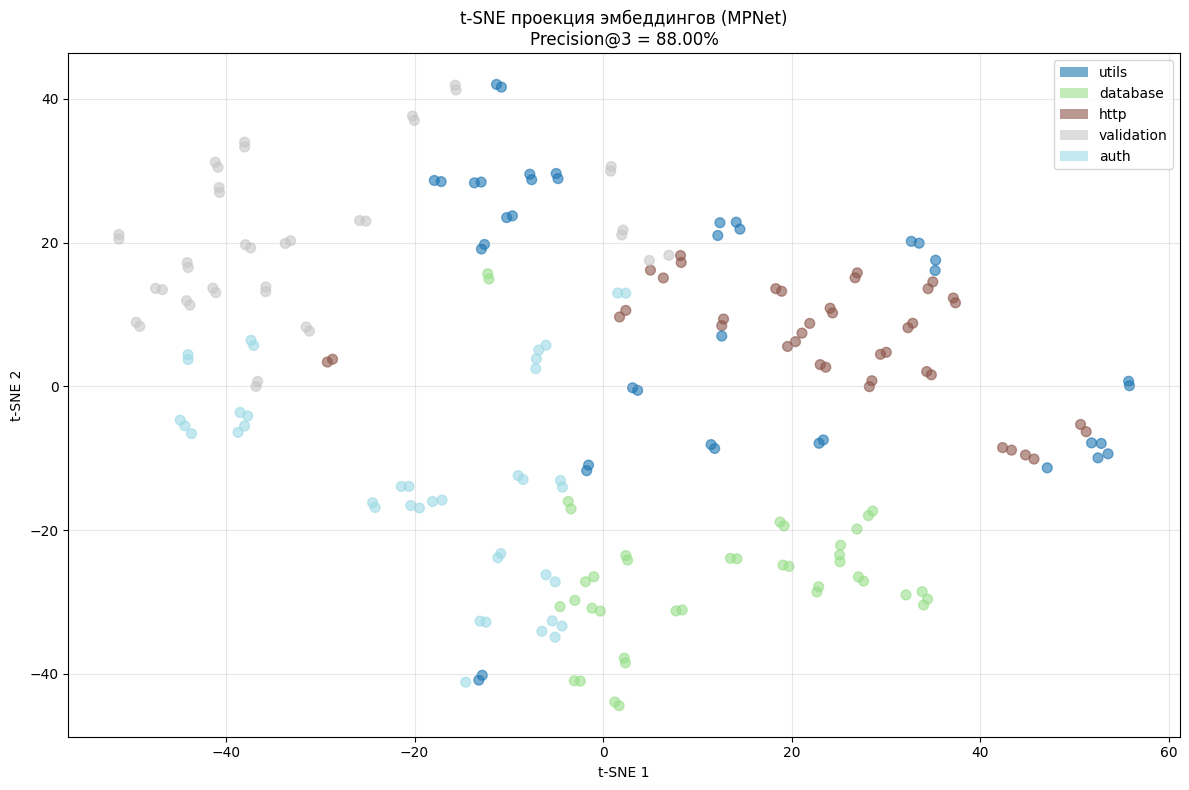


График построен!

ШАГ 3 ЗАВЕРШЕН!


In [11]:
# ============================================================================
# ШАГ 3. Метрика, таблица и визуализация
# ============================================================================

print("=" * 70)
print("ШАГ 3: Расчет метрик и визуализация")
print("=" * 70)

index_to_id = {}
for i, fragment in enumerate(code_corpus):
    index_to_id[i] = fragment['id']

def calculate_precision_at_3(results, correct_ids, index_to_id):
    correct_count = 0
    for i, top3_indices in enumerate(results):
        top3_ids = [index_to_id[idx] for idx in top3_indices]
        if correct_ids[i] in top3_ids:
            correct_count += 1
    precision = correct_count / len(results)
    return precision, correct_count

print("\nСчитаем метрику Precision@3...")
precision1, correct1 = calculate_precision_at_3(results_model1, correct_ids, index_to_id)
precision2, correct2 = calculate_precision_at_3(results_model2, correct_ids, index_to_id)

print(f"\nModel 1 (MiniLM):")
print(f"  Правильных ответов в топ-3: {correct1} из {len(correct_ids)}")
print(f"  Precision@3: {precision1:.4f} ({precision1*100:.2f}%)")

print(f"\nModel 2 (MPNet):")
print(f"  Правильных ответов в топ-3: {correct2} из {len(correct_ids)}")
print(f"  Precision@3: {precision2:.4f} ({precision2*100:.2f}%)")

if precision1 > precision2:
    best_model_name = "MiniLM"
    best_embeddings = embeddings_model1
    best_precision = precision1
else:
    best_model_name = "MPNet"
    best_embeddings = embeddings_model2
    best_precision = precision2

print(f"\nЛучшая модель: {best_model_name} (Precision@3 = {best_precision*100:.2f}%)")



# ТАБЛИЦА сравнения
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 70)

results_table = pd.DataFrame({
    'Модель': ['MiniLM', 'MPNet'],
    'Размерность': [384, 768],
    'Правильных в топ-3': [correct1, correct2],
    'Precision@3': [f"{precision1:.4f}", f"{precision2:.4f}"],
    'Precision@3 %': [f"{precision1*100:.2f}%", f"{precision2*100:.2f}%"]
})

print("\n", results_table.to_string(index=False))



# ВИЗУАЛИЗАЦИЯ: t-SNE
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ: t-SNE проекция лучшей модели")
print("=" * 70)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print(f"\nСтроим t-SNE проекцию для {best_model_name}...")

categories = [fragment.get('category', 'unknown') for fragment in code_corpus]
unique_categories = list(set(categories))
print(f"Категории: {unique_categories}")

print("Применяем t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d = tsne.fit_transform(best_embeddings)

print(f"Размерность после t-SNE: {embeddings_2d.shape}")

category_to_color = {}
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_categories)))
for i, cat in enumerate(unique_categories):
    category_to_color[cat] = colors[i]

point_colors = [category_to_color[cat] for cat in categories]

plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            c=point_colors, alpha=0.6, s=50)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=category_to_color[cat], label=cat, alpha=0.6) 
                   for cat in unique_categories]
plt.legend(handles=legend_elements, loc='best')

plt.title(f't-SNE проекция эмбеддингов ({best_model_name})\nPrecision@3 = {best_precision*100:.2f}%')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nГрафик построен!")
print("\n" + "=" * 70)
print("ШАГ 3 ЗАВЕРШЕН!")
print("=" * 70)